In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## Bài 1

## a)

In [22]:
def low_pass_filter(image: np.ndarray, threshold: float):
    # Bước 1: Biến đổi Fourier 2 chiều
    f_transform = np.fft.fft2(image)
    f_shifted = np.fft.fftshift(f_transform)

    # Bước 2: Loại bỏ các thành phần có biên độ lớn hơn threshold
    magnitude = np.abs(f_shifted)
    print(magnitude)
    mask = magnitude <= threshold
    f_filtered = f_shifted * mask

    # Bước 3: Biến đổi Fourier ngược
    f_ishift = np.fft.ifftshift(f_filtered)
    image_filtered = np.fft.ifft2(f_ishift)

    # Bước 4: Trả về ảnh sau lọc và phổ Fourier của ảnh sau lọc
    return image_filtered, f_filtered

## b)

[[ 849.          837.06251232  121.34143203 ...  637.67319052
   121.34143203  837.06251232]
 [ 942.61163669  895.88027585  961.2899257  ...  351.14129156
   970.61120249  652.76326508]
 [ 736.03738192 1152.71889634 1037.22936914 ...  508.51671521
   495.51643446  834.49213348]
 ...
 [ 298.12218324  136.73932156  311.06083251 ...  533.74500334
  1027.66497619  643.92837049]
 [ 736.03738192  834.49213348  495.51643446 ... 1225.03720814
  1037.22936914 1152.71889634]
 [ 942.61163669  652.76326508  970.61120249 ...  456.97321795
   961.2899257   895.88027585]]


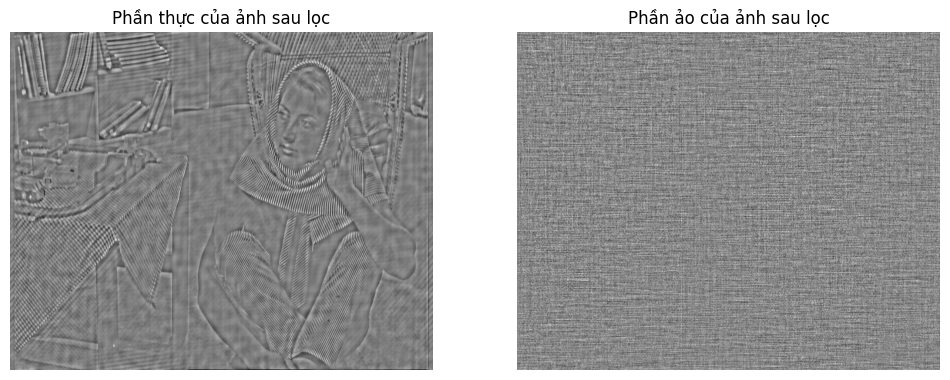

In [35]:
image = cv2.imread('/content/barbara.png', cv2.IMREAD_GRAYSCALE)

# Áp dụng bộ lọc thông thấp
filtered_image_complex, filtered_spectrum = low_pass_filter(image, threshold=100000)

# Hiển thị phần thực và phần ảo của ảnh sau lọc
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.real(filtered_image_complex), cmap='gray')
plt.title("Phần thực của ảnh sau lọc")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.imag(filtered_image_complex), cmap='gray')
plt.title("Phần ảo của ảnh sau lọc")
plt.axis('off')

plt.show()

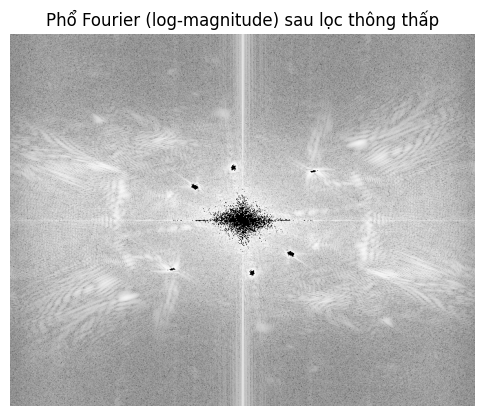

In [36]:
plt.figure(figsize=(6, 5))
spectrum_magnitude = np.log(1 + np.abs(filtered_spectrum))

plt.imshow(spectrum_magnitude, cmap='gray')
plt.title("Phổ Fourier (log-magnitude) sau lọc thông thấp")
plt.axis('off')
plt.show()

Real component contains main content of the high-frequency filtered => blurred image

Complex part is usually very small => image of complex part does not show any information

Blurry image is correct with the low-pass filter since it keeps the low-frequency components, remove high-frequency components

## Bài 2

## a)

In [48]:
def high_pass_filter(image: np.ndarray, threshold: float):
    # Bước 1: Biến đổi Fourier 2 chiều
    f_transform = np.fft.fft2(image)
    f_shifted = np.fft.fftshift(f_transform)

    # Bước 2: Loại bỏ các tần số có biên độ nhỏ hơn threshold
    magnitude = np.abs(f_shifted)
    print(magnitude.max(), magnitude.min())
    print(magnitude)
    mask = magnitude >= threshold
    f_filtered = f_shifted * mask

    # Bước 3: Biến đổi Fourier ngược
    f_ishift = np.fft.ifftshift(f_filtered)
    image_filtered = np.fft.ifft2(f_ishift)

    # Bước 4: Trả về ảnh sau lọc và phổ tương ứng
    return image_filtered, f_filtered


## b)

920965.0 18.16180176097368
[[ 737.20524776  378.18483226  176.9885738  ...  176.9885738
   378.18483226  737.20524776]
 [1386.36639465  458.2856752   680.49017402 ...  411.63163812
   966.871211   2093.33900393]
 [1152.81778427 1350.87320265 1187.59958597 ... 1637.0277137
   779.38361627 1335.83789664]
 ...
 [1649.03401682 1320.30553923 1108.0120643  ...  387.41405524
   737.88398119  611.32635716]
 [1335.83789664  779.38361627 1637.0277137  ... 1187.59958597
  1350.87320265 1152.81778427]
 [2093.33900393  966.871211    411.63163812 ...  680.49017402
   458.2856752  1386.36639465]]


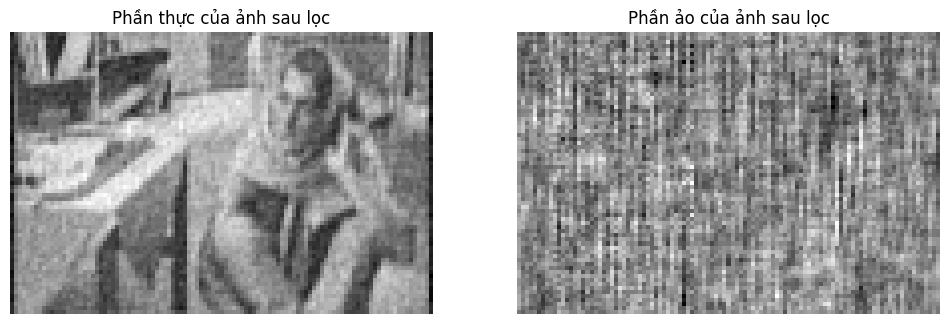

In [60]:
# Đọc ảnh xám
image = cv2.imread('/content/barbara_gaussian.png', cv2.IMREAD_GRAYSCALE)

# Áp dụng bộ lọc thông cao
filtered_image_complex, filtered_spectrum = high_pass_filter(image, threshold=2000)

# Hiển thị phần thực và ảo của ảnh sau lọc
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(np.real(filtered_image_complex), cmap='gray')
plt.title("Phần thực của ảnh sau lọc")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.imag(filtered_image_complex), cmap='gray')
plt.title("Phần ảo của ảnh sau lọc")
plt.axis('off')

plt.show()

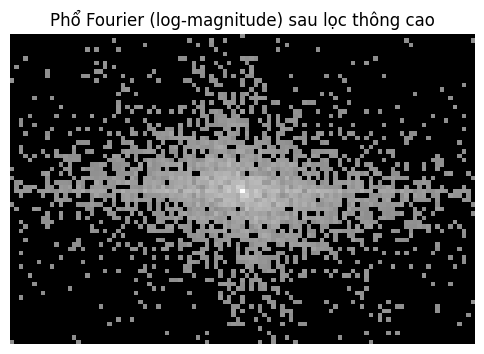

In [61]:
plt.figure(figsize=(6, 5))
spectrum_magnitude = np.log(1 + np.abs(filtered_spectrum))

plt.imshow(spectrum_magnitude, cmap='gray')
plt.title("Phổ Fourier (log-magnitude) sau lọc thông cao")
plt.axis('off')
plt.show()

The real part of the image after high-pass filter will highlight the border, edge or noise - components in the high frequency. Because the original image was blurred using Gaussian filter, high-pass filter can reconstruct the loss details.

The complex part is still very small, does not show information. It is due to the error in the calculation of the Fourier transformation.

Result is the image with borders, edges and more detail but can be affected by noises



## Bài 3

In [62]:
def blur_detection(image: np.ndarray, size: int, threshold: float, visualize=False):
    # Bước 1: DFT 2D
    f_transform = np.fft.fft2(image)

    # Bước 2: Dịch chuyển DC vào trung tâm
    f_shifted = np.fft.fftshift(f_transform)

    # Bước 3: Loại bỏ vùng tần số thấp (trung tâm)
    h, w = image.shape
    cy, cx = h // 2, w // 2
    f_shifted[cy-size:cy+size, cx-size:cx+size] = 0

    # Bước 4: Biến đổi ngược
    f_ishift = np.fft.ifftshift(f_shifted)
    I = np.fft.ifft2(f_ishift)

    # Bước 5: Tính độ lớn (magnitude) và chuyển sang log scale
    magnitude_map = 20 * np.log(np.abs(I) + 1e-5)  # tránh log(0)
    mean_magnitude = np.mean(magnitude_map)

    if visualize:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title("Ảnh gốc hoặc làm mờ")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(magnitude_map, cmap='jet')
        plt.title(f"Blur Magnitude Map (mean={mean_magnitude:.2f})")
        plt.axis('off')
        plt.show()

    # Bước 6: Phân loại mờ/rõ
    if mean_magnitude < threshold:
        return "Blurred", mean_magnitude
    else:
        return "Sharp", mean_magnitude


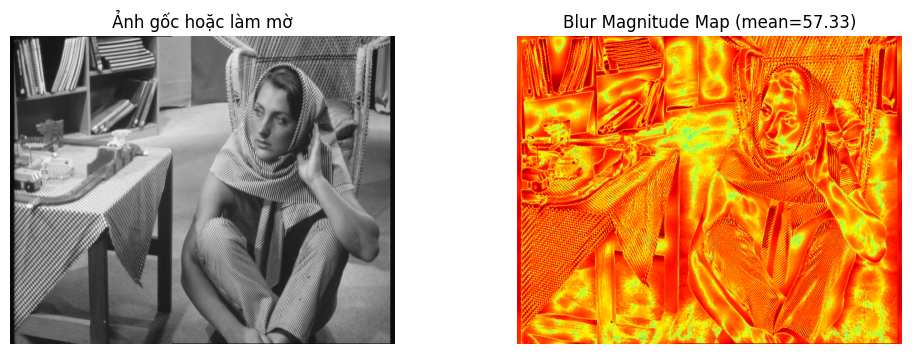

Original: Sharp (mean = 57.33)


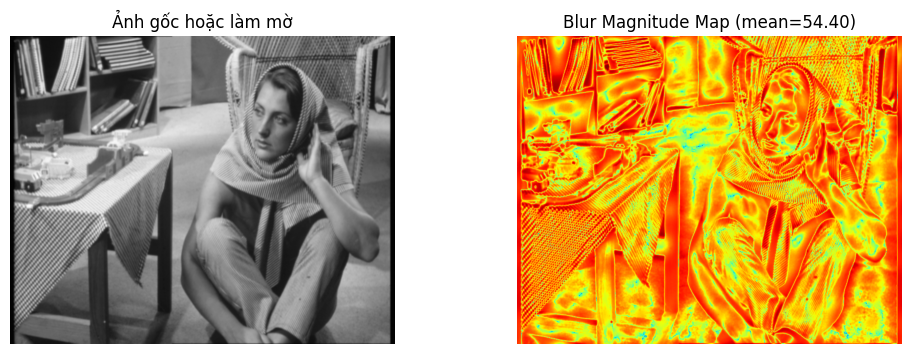

Blurred 3x3: Sharp (mean = 54.40)


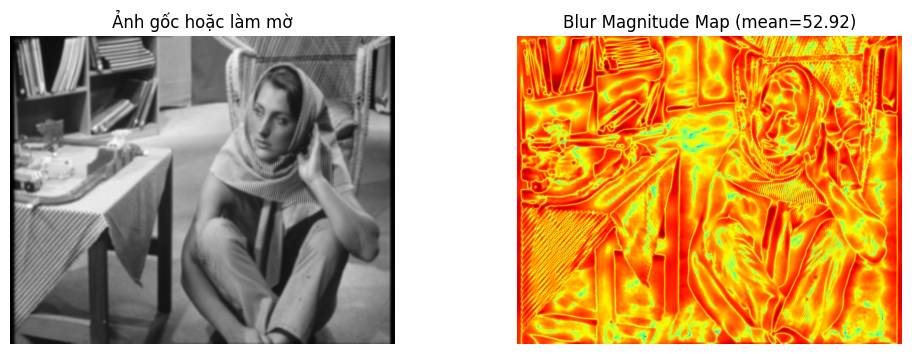

Blurred 5x5: Blurred (mean = 52.92)


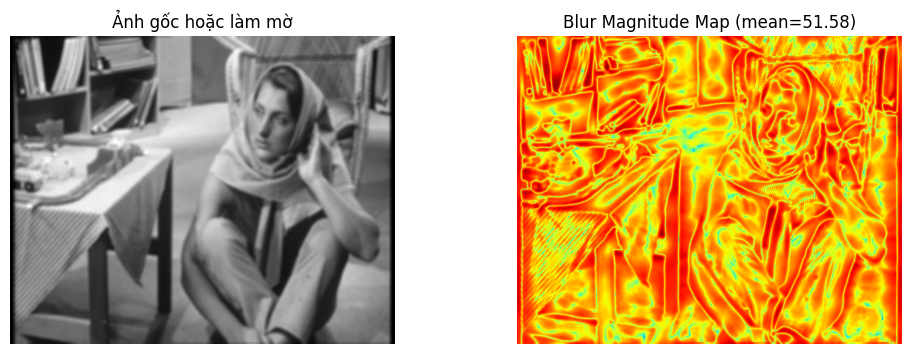

Blurred 7x7: Blurred (mean = 51.58)


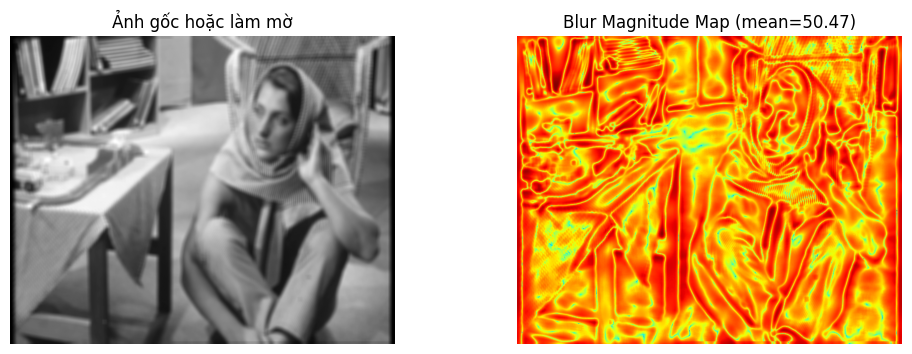

Blurred 9x9: Blurred (mean = 50.47)


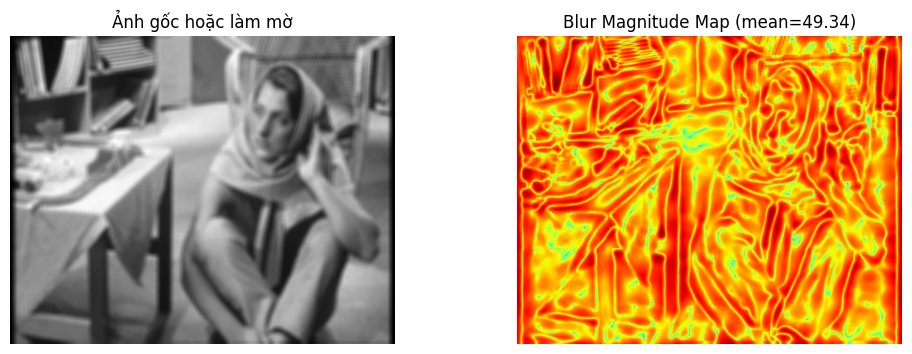

Blurred 11x11: Blurred (mean = 49.34)


In [68]:
image = cv2.imread("/content/barbara.png", cv2.IMREAD_GRAYSCALE)

# Ngưỡng phân biệt mờ/rõ và size vùng DC
threshold = 53.0
size = 10

# Ảnh gốc
label, val = blur_detection(image, size, threshold, visualize=True)
print(f"Original: {label} (mean = {val:.2f})")

# Áp dụng làm mờ trung bình 3x3 đến 11x11
for k in range(3, 12, 2):
    blurred = cv2.blur(image, (k, k))
    label, val = blur_detection(blurred, size, threshold, visualize=True)
    print(f"Blurred {k}x{k}: {label} (mean = {val:.2f})")

Original image will have high mean of magnitude => Sharp.

Blurred image with higher filter will have less high-frequency component, so removed region DC will affect more => Lower mean => Blurred.

Threshold can be fine-tuned based on actual image.

## Bài 4

## USE BARTON-2 AND BARTON2-WINDOW IMAGE FROM 9.1 LAB, THE LAB11 VERSION IS TOO BLURRY

In [81]:
import time

def template_matching_fourier(image_path, template_path):
    # Read as color (RGB)
    image_bgr = cv2.imread(image_path)
    template_bgr = cv2.imread(template_path)

    # Convert to RGB
    image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    template = cv2.cvtColor(template_bgr, cv2.COLOR_BGR2RGB)

    h, w, c = image.shape
    th, tw, _ = template.shape

    correlation_sum = np.zeros((h, w))

    # Per-channel processing
    for i in range(3):  # R, G, B
        padded_template = np.zeros((h, w))
        padded_template[:th, :tw] = template[:, :, i]

        # Compute DFTs
        F_image = np.fft.fft2(image[:, :, i])
        F_template = np.fft.fft2(padded_template)

        # Cross-correlation in frequency domain
        cross_power_spectrum = F_image * np.conj(F_template)
        correlation = np.fft.ifft2(cross_power_spectrum)
        correlation_real = np.real(correlation)

        correlation_sum += correlation_real

    # Normalize and get max location
    correlation_avg = correlation_sum / 3.0
    y, x = np.unravel_index(np.argmax(correlation_avg), correlation_avg.shape)

    # Draw rectangle
    result_img = image.copy()
    cv2.rectangle(result_img, (x, y), (x + tw, y + th), (255, 0, 0), 2)

    # Show result
    plt.figure(figsize=(8, 5))
    plt.imshow(result_img)
    plt.title(f"Matched by Fourier at ({x}, {y})")
    plt.axis('off')
    plt.show()

    return (x, y)



In [82]:
def template_matching_opencv(image_path, template_path):
    # Read grayscale images
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    assert image is not None, f"Could not read {image_path}"
    template = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)
    assert template is not None, f"Could not read {template_path}"

    h, w = template.shape

    # Methods for comparison
    methods = ['TM_CCOEFF', 'TM_CCOEFF_NORMED', 'TM_CCORR',
               'TM_CCORR_NORMED', 'TM_SQDIFF', 'TM_SQDIFF_NORMED']

    best_pos = None

    for meth in methods:
        img = image.copy()
        method = getattr(cv2, meth)

        # Apply template matching
        result = cv2.matchTemplate(img, template, method)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

        # Determine best match
        if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
            top_left = min_loc
        else:
            top_left = max_loc

        bottom_right = (top_left[0] + w, top_left[1] + h)

        # Draw rectangle
        img_color = cv2.imread(image_path)
        cv2.rectangle(img_color, top_left, bottom_right, (255, 0, 0), 2)

        # Display result
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(result, cmap='gray')
        plt.title('Matching Result'), plt.xticks([]), plt.yticks([])
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
        plt.title(f'Detected Point: {meth}'), plt.xticks([]), plt.yticks([])
        plt.suptitle(f'Method: {meth}')
        plt.show()

        # Optionally return the best result
        if meth == 'TM_CCORR_NORMED':
            best_pos = top_left

    return best_pos

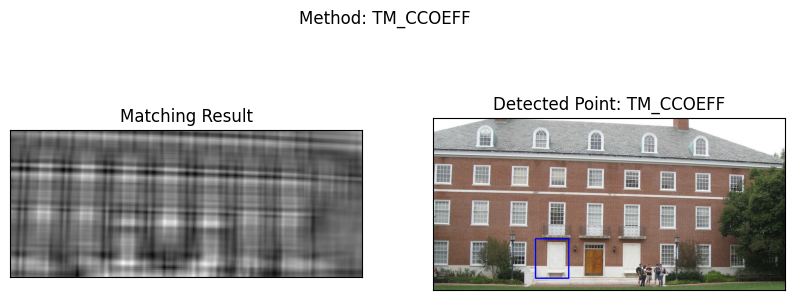

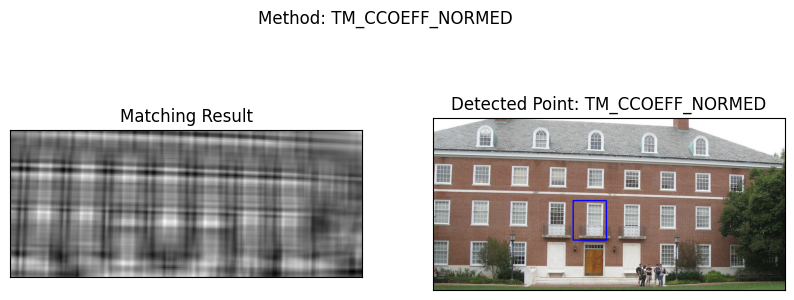

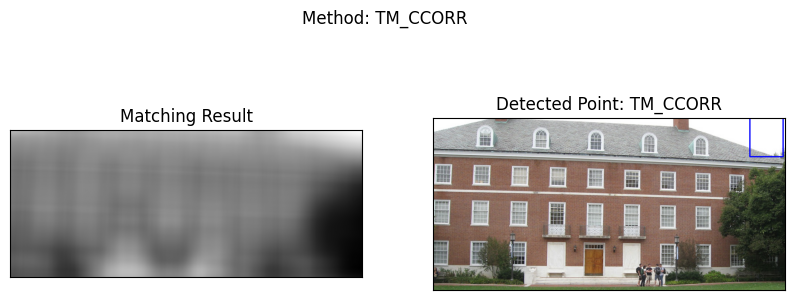

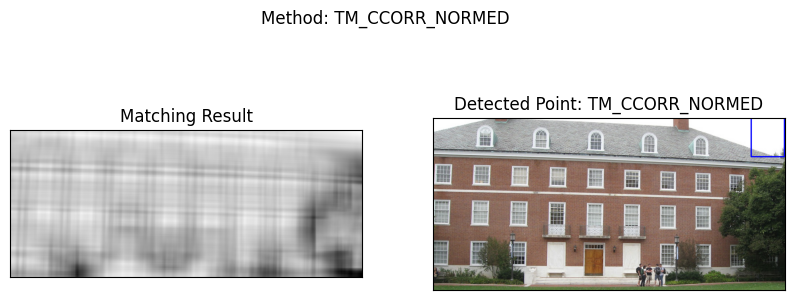

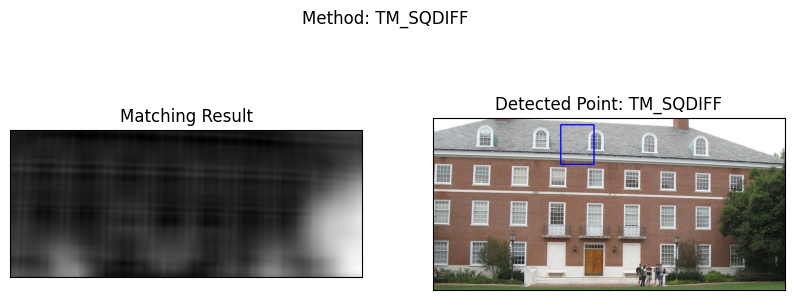

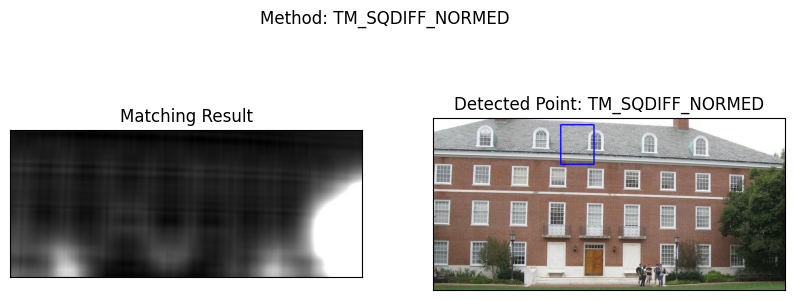

OpenCV Matching Time: 1.2764s


In [83]:
# Đo thời gian OpenCV
start = time.time()
pos_opencv = template_matching_opencv("/content/barton2.jpg", "/content/barton2-window.jpg")
end = time.time()
print(f"OpenCV Matching Time: {end - start:.4f}s")

In [84]:
def best_template_opencv(image_path, template_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    template = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)
    th, tw = template.shape

    # Match bằng OpenCV
    result = cv2.matchTemplate(image, template, cv2.TM_CCOEFF_NORMED)
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)
    x, y = max_loc

    # Vẽ khung
    image_bgr = cv2.imread(image_path)
    cv2.rectangle(image_bgr, (x, y), (x + tw, y + th), (255, 0, 0), 2)

    # Hiển thị
    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Matched by OpenCV at ({}, {})".format(x, y))
    plt.axis('off')
    plt.show()

    return (x, y)

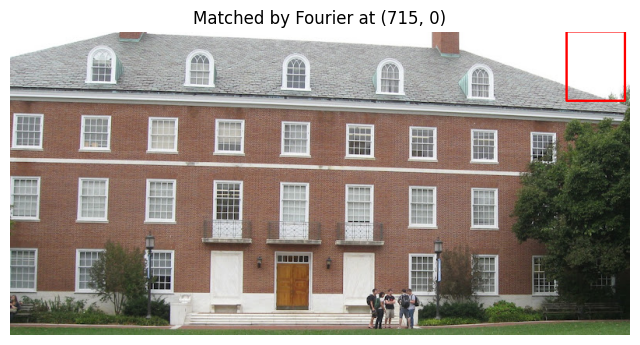

Fourier Matching Time: 0.7022s


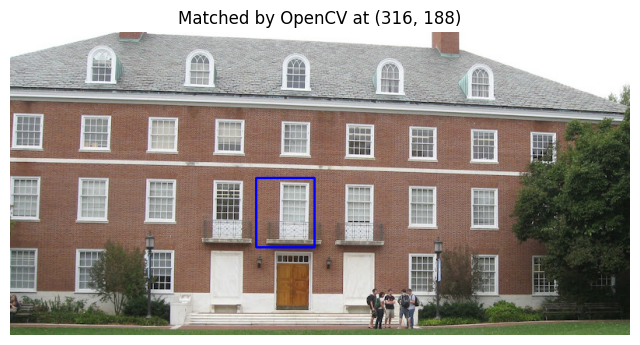

OpenCV Matching Time: 0.3306s


In [85]:
# Đo thời gian Fourier
start = time.time()
pos_fourier = template_matching_fourier("/content/barton2.jpg", "/content/barton2-window.jpg")
end = time.time()
print(f"Fourier Matching Time: {end - start:.4f}s")

# Đo thời gian OpenCV
start = time.time()
pos_opencv = best_template_opencv("/content/barton2.jpg", "/content/barton2-window.jpg")
end = time.time()
print(f"OpenCV Matching Time: {end - start:.4f}s")